### Beispiel Pruning

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Iris-Daten laden
iris = load_iris()
x = iris.data
y = iris.target

# Daten in Training und Test splitten
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=999) 

# Modell mit Pruning
model_pruning = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_leaf=5,
    min_impurity_decrease=0.1,
    random_state=42
)

# Modell trainieren
model_pruning.fit(X_train, y_train)

# Vorhersagen
y_pred = model_pruning.predict(X_test)

# Genauigkeit berechnen
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy mit pruning: "+ str(accuracy))

# Modell ohne Pruning
model_without_pruning = DecisionTreeClassifier(
    random_state=42
)
model_pruning.fit(X_train, y_train)
y_pred = model_pruning.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) 
print("Accuracy ohne pruning: "+str(accuracy)) #Auf Folien mit Pruning 0.92, ohne 0.97

Accuracy mit pruning: 0.9166666666666666
Accuracy ohne pruning: 0.9166666666666666


### Beispiel Grid Search

In [28]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=999)

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 4, 10], 
    'min_samples_leaf': [1, 2, 4],
}

cv_splitter = KFold(n_splits=5, shuffle=False)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv_splitter
)

grid_search.fit(X_train, y_train)
print("Beste Parameter: ", grid_search.best_params_)
print("Beste Genauigkeit: ", grid_search.best_score_)

Beste Parameter:  {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Beste Genauigkeit:  0.9555555555555555


- Man probiert 3^(3) * 5 Möglichkeiten aus, um die besten Parameter zu finden 

Feature Importances:  [0.         0.02511161 0.90769788 0.06719052]


Text(0.5, 1.0, 'Feature  Importances')

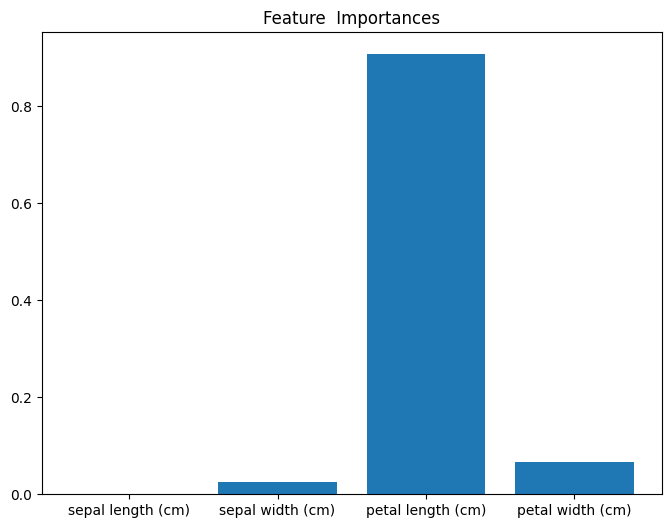

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=999)

# Modell trainieren
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42) # Begrenzung der Baumtiefe für bessere Lesbarkeit
tree_clf.fit(X_train, y_train)
feature_names = iris.feature_names
print("Feature Importances: ", tree_clf.feature_importances_)

plt.figure(figsize=(8,6))
plt.bar(range(len(tree_clf.feature_importances_)), tree_clf.feature_importances_, tick_label = feature_names)
plt.title("Feature  Importances")